In [1]:
import pandas as pd

df = pd.read_csv("../../output/domain_cath_pred/test_predicted.csv")

In [2]:
df.columns

Index(['domain_id', 'domain_start', 'domain_end', 'class', 'architecture',
       'topology', 'homology', 'protein_sequence', 'real_domain_start',
       'real_domain_end', 'cath', 'protein_length', 'protein_id',
       'protein_chain_id', 'cath_prediction'],
      dtype='object')

In [3]:
import colorsys
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
import os


def get_cath_color(cath_string, plot_seed=0):
    """Generate RGBA color for CATH domain with consistent class colors but varied shades per plot."""
    if cath_string == "NO_DOMAIN_REGION" or pd.isna(cath_string):
        return mcolors.to_rgba('lightgray', alpha=0.7)
    
    class_id = str(cath_string).split('.')[0] if '.' in str(cath_string) else None
    
    # Fixed base hues for CATH classes
    class_hues = {'1': 0.0, '2': 0.66, '3': 0.33, '4': 0.15}
    base_hue = class_hues.get(class_id, 0.5)
    
    # Generate unique variations per plot while keeping class consistency
    label_hash = hash(str(cath_string))
    hue_seed = label_hash + plot_seed * 113
    sat_seed = label_hash + plot_seed * 137
    val_seed = label_hash + plot_seed * 151
    
    hue_shift = (hash(hue_seed) % 1000) / 1000.0 * 0.4 - 0.2  # ±20% shift
    hue = (base_hue + hue_shift) % 1.0
    
    saturation = 0.2 + (hash(sat_seed) % 1000) / 1000.0 * 0.8  # 0.2-1.0
    value = 0.3 + (hash(val_seed) % 1000) / 1000.0 * 0.7      # 0.3-1.0
    
    r, g, b = colorsys.hsv_to_rgb(hue, np.clip(saturation, 0, 1), np.clip(value, 0, 1))
    return (r, g, b, 1.0)


def visualize_cath_predictions(df, output_dir, num_visualizations=5):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    os.makedirs(output_dir, exist_ok=True)
    
    for i, row in df.head(num_visualizations).iterrows():
        domain_id = row['domain_id']
        protein_length = int(row['protein_length'])
        true_cath = row['cath']
        pred_cath = row['cath_prediction']
        
        # Generate plot-specific seed for consistent but varied colors
        plot_seed = hash(str(domain_id))
        
        # Create per-residue labels
        true_labels = ["NO_DOMAIN_REGION"] * protein_length
        pred_labels = ["NO_DOMAIN_REGION"] * protein_length
        
        # Assign TRUE domain labels
        real_start = int(row['real_domain_start'])
        real_end = int(row['real_domain_end'])
        for pos in range(real_start, min(real_end + 1, protein_length)):
            true_labels[pos] = true_cath
        
        # Assign PREDICTED domain labels
        pred_start = int(row['domain_start'])
        pred_end = int(row['domain_end'])
        for pos in range(pred_start, min(pred_end + 1, protein_length)):
            pred_labels[pos] = pred_cath
        
        # Unique labels and color mapping
        all_labels = sorted(list(set(true_labels + pred_labels)))
        label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
        label_colors = {label: get_cath_color(label, plot_seed) for label in all_labels}
        
        cmap_colors = [label_colors[label] for label in all_labels]
        custom_cmap = mcolors.ListedColormap(cmap_colors)
        
        true_values = [label_to_idx[label] for label in true_labels]
        pred_values = [label_to_idx[label] for label in pred_labels]
        
        # Bigger figure for presentation
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8), sharex=True)
        fig.suptitle(f"Domain {domain_id}",
                     fontsize=24, fontweight='bold')
        
        vmax = len(all_labels) - 1 if len(all_labels) > 1 else 1
        
        # True labels plot
        ax1.imshow(np.array(true_values).reshape(1, -1), cmap=custom_cmap, aspect='auto',
                   extent=[0, protein_length, 0, 1], vmin=0, vmax=vmax)
        ax1.set_yticks([])
        ax1.set_title("True CATH Domains", fontsize=20, fontweight='bold')
        ax1.set_ylabel("True", fontsize=18, fontweight='bold')
        ax1.tick_params(axis='x', labelsize=16)
        
        # Predicted labels plot
        ax2.imshow(np.array(pred_values).reshape(1, -1), cmap=custom_cmap, aspect='auto',
                   extent=[0, protein_length, 0, 1], vmin=0, vmax=vmax)
        ax2.set_yticks([])
        ax2.set_title("Predicted CATH Domains", fontsize=20, fontweight='bold')
        ax2.set_xlabel("Residue Index", fontsize=18, fontweight='bold')
        ax2.set_ylabel("Predicted", fontsize=18, fontweight='bold')
        ax2.tick_params(axis='x', labelsize=16)
        
        # Bigger legend
        handles = [plt.Rectangle((0, 0), 1, 1, color=label_colors[label]) for label in all_labels]
        ax2.legend(handles, all_labels, loc='upper center', bbox_to_anchor=(0.5, -0.3),
                   fancybox=True, shadow=True, ncol=3, fontsize=16, frameon=True)
        
        plt.tight_layout(rect=[0, 0.05, 1, 0.93])
        plt.savefig(os.path.join(output_dir, f"{i}_{domain_id}.png"), dpi=300)
        plt.close(fig)
        
        print(f"Generated visualization for protein {i+1}: {domain_id}")



# Usage example:
#visualize_cath_predictions(df, "output_visualizations", num_visualizations=150)

In [4]:
df[df["protein_chain_id"] == "2rd5A"]

,domain_id,domain_start,domain_end,class,architecture,topology,homology,protein_sequence,real_domain_start,real_domain_end,cath,protein_length,protein_id,protein_chain_id,cath_prediction
1230,2rd5A00,23,290,3,40,1160,10,MTVSTPPSIATGNAPSPDYRVEILSESLPFIQKFRGKTIVVKYGGA...,18,298,3.40.1160.10,298,2rd5,2rd5A,3.40.1160.10


In [7]:
import os
import py3Dmol
import matplotlib.colors as mcolors


# ---------- Setup ----------
# Create output directory if it doesn't exist
output_dir = "3d_visualizations"
os.makedirs(output_dir, exist_ok=True)

#100, 3
colors = ['#666666', '#6FB2E4', '#0d82d9', '#C43F7B']
# Select domain index
domain_index = 1230

# Get protein and domain info
protein_id = df["protein_id"][domain_index]
domain_start = df["domain_start"][domain_index]
domain_end = df["domain_end"][domain_index]

print(protein_id)

real_domain_start = df["real_domain_start"][domain_index]
real_domain_end = df["real_domain_end"][domain_index]

# Get colors for visualization
color_actual = mcolors.to_hex(get_cath_color(df["cath"][domain_index])[:3])
color_predicted = mcolors.to_hex(get_cath_color(df["cath_prediction"][domain_index])[:3])

# ---------- View 1: Predicted Domain ----------
view_predicted = py3Dmol.view(query='pdb:' + protein_id)
view_predicted.setStyle({'cartoon': {'color': '#E0E0E0'}})
view_predicted.addStyle({'resi': f"{domain_start}-{domain_end}"}, {'cartoon': {'color': "#0d82d9"}})
view_predicted.zoomTo()

# Show in notebook (optional)
view_predicted.show()

# ---------- View 2: Actual Domain ----------
view_actual = py3Dmol.view(query='pdb:' + protein_id)
view_actual.setStyle({'cartoon': {'color': '#E0E0E0'}})
view_actual.addStyle({'resi': f"{real_domain_start}-{real_domain_end}"}, {'cartoon': {'color': "#C43F7B"}})
view_actual.zoomTo()

# Show in notebook (optional)
view_actual.show()

2rd5


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

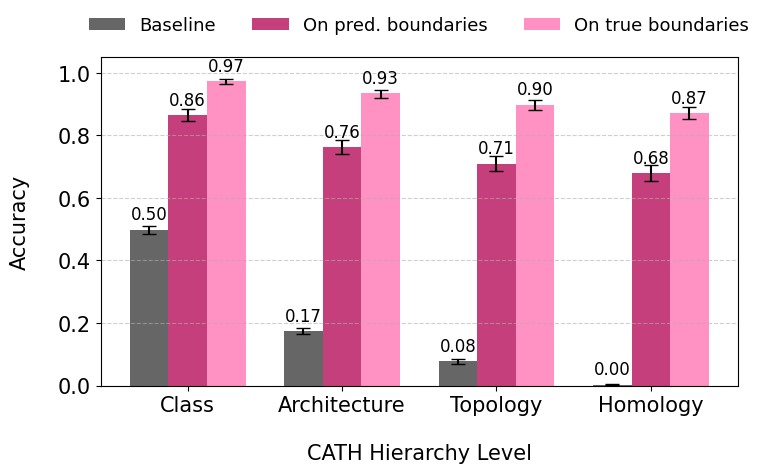

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Data
levels = ["Class", "Architecture", "Topology", "Homology"]
x = np.arange(len(levels))
bar_width = 0.25

# Accuracy and CI values
baseline_accuracy = [0.498, 0.173, 0.077, 0.003]
baseline_ci_lower = [0.485, 0.166, 0.070, 0.003]
baseline_ci_upper = [0.510, 0.184, 0.084, 0.005]

combined_accuracy = [0.8650, 0.7629, 0.7094, 0.6793]
combined_ci_lower = [0.8470, 0.7405, 0.6855, 0.6547]
combined_ci_upper = [0.8835, 0.7848, 0.7334, 0.7041]

model_accuracy = [0.9732, 0.9339, 0.8984, 0.8714]
model_ci_lower = [0.9643, 0.9207, 0.8821, 0.8535]
model_ci_upper = [0.9814, 0.9464, 0.9128, 0.8892]

# Error calculations
baseline_error = [np.array(baseline_accuracy) - np.array(baseline_ci_lower),
                  np.array(baseline_ci_upper) - np.array(baseline_accuracy)]
combined_error = [np.array(combined_accuracy) - np.array(combined_ci_lower),
                  np.array(combined_ci_upper) - np.array(combined_accuracy)]
model_error = [np.array(model_accuracy) - np.array(model_ci_lower),
               np.array(model_ci_upper) - np.array(model_accuracy)]

# Custom shades
colors = ['#666666', '#C43F7B', '#ff91c3']

plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 15})

# Plot bars
bars1 = plt.bar(x - bar_width, baseline_accuracy, width=bar_width,
                yerr=baseline_error, capsize=5, label='Baseline', color=colors[0])
bars2 = plt.bar(x, combined_accuracy, width=bar_width,
                yerr=combined_error, capsize=5, label='On pred. boundaries', color=colors[1])
bars3 = plt.bar(x + bar_width, model_accuracy, width=bar_width,
                yerr=model_error, capsize=5, label='On true boundaries', color=colors[2])

# Add text on top of bars
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=12)

label_bars(bars1)
label_bars(bars2)
label_bars(bars3)

# Formatting
plt.xticks(x, levels)
plt.ylabel("Accuracy", labelpad=20)
plt.xlabel("CATH Hierarchy Level", labelpad=20)
# Place legend above the plot
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, frameon=False, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.ylim(0, 1.05)  # Add room for text above bars

plt.show()


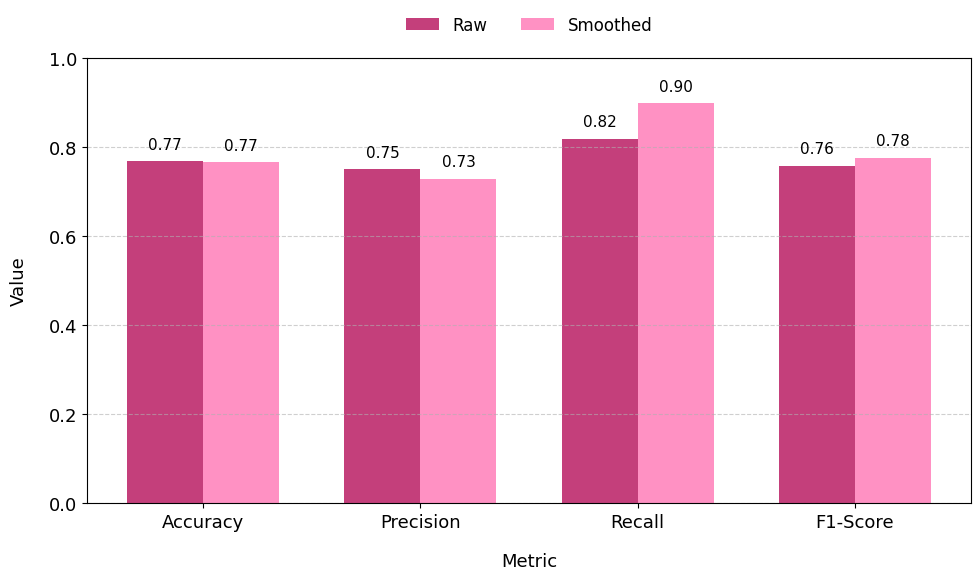

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the user (excluding Avg Fragments)
methods = ['Raw', 'Smoothed']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [
    [0.769, 0.750, 0.819, 0.758],   # Raw
    [0.766, 0.729, 0.898, 0.776]    # Smoothed
]

# Convert to numpy array for easier manipulation
values = np.array(values)

# Custom colors
colors = ['#C43F7B', '#ff91c3']

# Plot settings
x = np.arange(len(metrics))
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 13})

# Plotting the bars
bars1 = plt.bar(x - bar_width/2, values[0], width=bar_width, label='Raw', color=colors[0])
bars2 = plt.bar(x + bar_width/2, values[1], width=bar_width, label='Smoothed', color=colors[1])

# Add text on top of bars
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=11)

label_bars(bars1)
label_bars(bars2)

# Formatting
plt.xticks(x, metrics)
plt.ylabel("Value", labelpad=15)
plt.xlabel("Metric", labelpad=15)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
           ncol=2, frameon=False, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.ylim(0, 1.0)

plt.show()


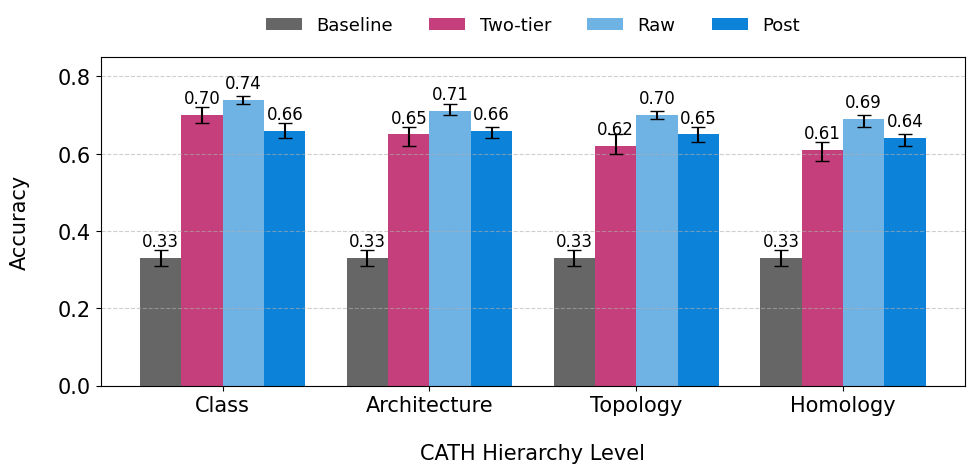

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Data
levels = ["Class", "Architecture", "Topology", "Homology"]
x = np.arange(len(levels))
bar_width = 0.2

# Accuracy and CI values
baseline_accuracy = [0.33, 0.33, 0.33, 0.33]
baseline_ci_lower = [0.31, 0.31, 0.31, 0.31]
baseline_ci_upper = [0.35, 0.35, 0.35, 0.35]

raw_accuracy = [0.74, 0.71, 0.70, 0.69]
raw_ci_lower = [0.73, 0.70, 0.69, 0.67]
raw_ci_upper = [0.75, 0.73, 0.71, 0.70]

post_accuracy = [0.66, 0.66, 0.65, 0.64]
post_ci_lower = [0.64, 0.64, 0.63, 0.62]
post_ci_upper = [0.68, 0.67, 0.67, 0.65]

two_tier_accuracy = [0.70, 0.65, 0.62, 0.61]
two_tier_ci_lower = [0.68, 0.62, 0.60, 0.58]
two_tier_ci_upper = [0.72, 0.67, 0.65, 0.63]

# Error calculations
baseline_error = [np.array(baseline_accuracy) - np.array(baseline_ci_lower),
                  np.array(baseline_ci_upper) - np.array(baseline_accuracy)]
raw_error = [np.array(raw_accuracy) - np.array(raw_ci_lower),
             np.array(raw_ci_upper) - np.array(raw_accuracy)]
post_error = [np.array(post_accuracy) - np.array(post_ci_lower),
              np.array(post_ci_upper) - np.array(post_accuracy)]
two_tier_error = [np.array(two_tier_accuracy) - np.array(two_tier_ci_lower),
                  np.array(two_tier_ci_upper) - np.array(two_tier_accuracy)]

# Custom colors
colors = ['#666666', '#6FB2E4', '#0d82d9', '#C43F7B']

plt.figure(figsize=(10, 5))
plt.rcParams.update({'font.size': 15})

# Plot bars
bars1 = plt.bar(x - 1.5*bar_width, baseline_accuracy, width=bar_width,
                yerr=baseline_error, capsize=5, label='Baseline', color=colors[0])
bars2 = plt.bar(x - 0.5*bar_width, two_tier_accuracy, width=bar_width,
                yerr=two_tier_error, capsize=5, label='Two-tier', color=colors[3])
bars3 = plt.bar(x + 0.5*bar_width, raw_accuracy, width=bar_width,
                yerr=raw_error, capsize=5, label='Raw', color=colors[1])
bars4 = plt.bar(x + 1.5*bar_width, post_accuracy, width=bar_width,
                yerr=post_error, capsize=5, label='Post', color=colors[2])

# Add text on top of bars
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=12)

label_bars(bars1)
label_bars(bars2)
label_bars(bars3)
label_bars(bars4)

# Formatting
plt.xticks(x, levels)
plt.ylabel("Accuracy", labelpad=20)
plt.xlabel("CATH Hierarchy Level", labelpad=20)
# Place legend above the plot
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
           ncol=4, frameon=False, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.ylim(0, 0.85)  # Adjusted for the data range

plt.show()